# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [197]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from arch import arch_model

### Загрузка исторических цен акций (закрытия на конец дня) и расчёт ежедневных доходностей

In [198]:
tickers = ['MSFT', 'AAPL']
start_date = '2023-01-01'
end_date = '2025-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

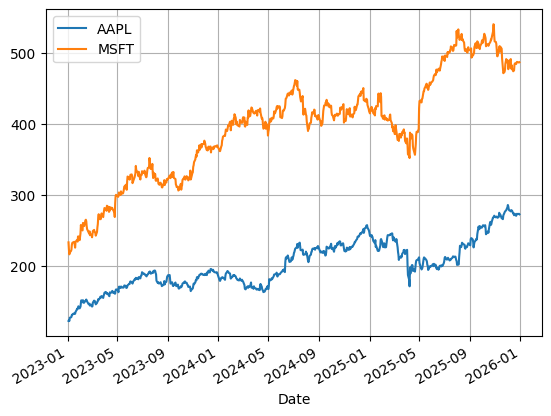

In [199]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### График доходностей


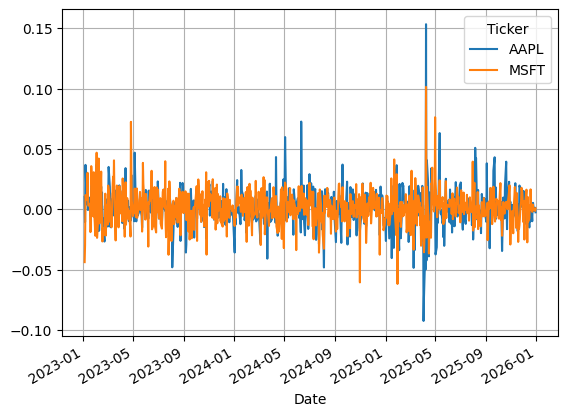

In [200]:
returns.plot()
plt.grid()
plt.show()

### Описательные статистики дневных доходностей

In [201]:
returns.describe()

Ticker,AAPL,MSFT
count,750.000000,750.000000
mean,0.001191,0.001085
std,0.016137,0.014624
min,-0.092456,-0.061809
25%,-0.006654,-0.006728
50%,0.001400,0.001252
75%,0.008725,0.009156
max,0.153288,0.101337


### Графики Бокса-Вискера дневных доходностей

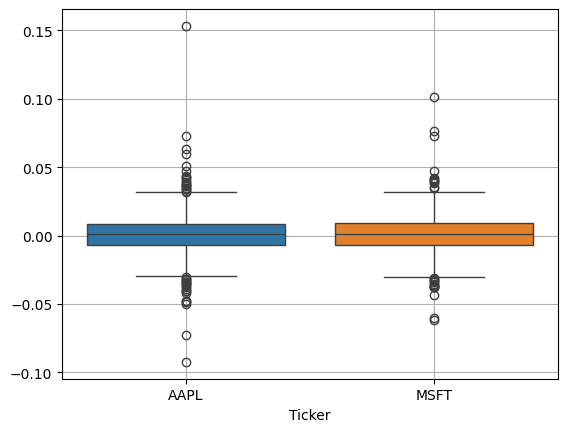

In [202]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

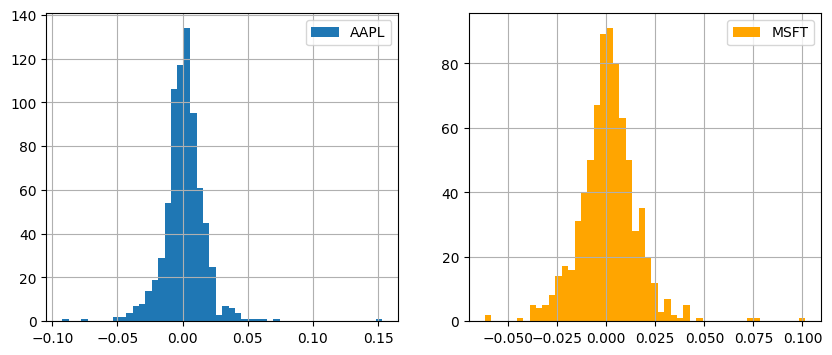

In [203]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### Критерии стационарности ряда: ADF-test и KPSS-test

In [204]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -27.857260
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.439110818166223), '5%': np.float64(-2.8654065210185795), '10%': np.float64(-2.568828945705979)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.207102
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -13.891039
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4391580196774494), '5%': np.float64(-2.8654273226340554), '10%': np.float64(-2.5688400274762397)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.101721
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/tmp/ipykernel_3752/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_3752/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


### p-value обоих тестов близко к нулю, ряды стационарны. Значит, можно на их основе построить GARCH-модель

## 2. Построение модели GARCH(1,1) на основе случайных величин

Модель GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) для временного ряда доходностей $r_t$ записывается как: $$\begin{gathered} r_t = \mu + \varepsilon_t, \\ \varepsilon_t=\sigma_t z_t, \\ \sigma^2_t=\omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} \end{gathered} $$  где $r_t$ - исследуемый ряд, $z_t$ - случайные величины, $\omega > 0$, $\alpha, \beta \ge 0$, $\alpha + \beta < 1$ (условие стационарности). $\mu$ задаётся в зависимости от центрированности ряда.
На реальных данных параметры чаще всего оцениваются методом максимального правдоподобия. Процесс $r_t$ должен быть процессом с условной гетероскедакстичностью, т. е. может быть представлен следующим образом $r_t = \sigma_t z_t$  

Для предсказания будущей волатильности используется формулы: $$\begin{gathered} \hat{\sigma}^2_{t+1} = \omega + \alpha \varepsilon^2_t + \beta \sigma^2_{t} \\ \hat{\sigma}^2_{t+h} = \omega + (\alpha + \beta) \hat{\sigma}^2_{t+h-1},\ \ h=2,3,\dots \end{gathered}$$

В рамках лабораторной работы для симуляции временных рядов и построения на них модели GARCH, зададим истинные значения $\omega, \alpha, \beta$ и построим ряды из приведённых формул, а затем оценим, как модель оценит эти параметры. $\omega = 0.1, \alpha = 0.1, \beta = 0.8$

In [205]:
def simulate_garch_process(omega: float, alpha: float, beta: float, T: int, distribution, *args):
    r = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / (1 - alpha - beta)

    for t in range(1, T):
        sigma2[t] = omega + alpha * (r[t-1]**2) + beta * sigma2[t-1]
        r[t] = np.sqrt(sigma2[t]) * distribution(*args)

    return r, sigma2

OMEGA = 0.1
ALPHA = 0.1
BETA = 0.8
T = 1000
PREDICTION_STEPS = 20

In [206]:
from typing import Literal

from scipy.optimize import minimize, LinearConstraint
from scipy import special

class garch11:
    def __init__(self, dist: Literal['norm', "vg", "as"]):
        self.dist = dist
        self.conditional_volatility = np.zeros(1)

    def fit(self, sample):
        init_params = [0., 0.01, 0.1, 0.8]
        bounds = [(None, None), (1e-6, None), (0, 1), (0, 1)]
        constraint = LinearConstraint([[0, 0, 1, 1]], ub=0.999)

        result = None
        sigma2, mu, omega, alpha, beta, eps = np.zeros(0), 0., 0., 0., 0., np.zeros(0)
        T = len(sample)

        if self.dist == 'norm':
            result = minimize(self.likelihood_normal, init_params,
                              method='SLSQP', args=(sample),
                              bounds=bounds, constraints=constraint)
            mu, omega, alpha, beta = result.x
            
        elif self.dist == 'vg':
            result = minimize(self.likelihood_vg, init_params,
                              method='SLSQP', args=(sample),
                              bounds=bounds, constraints=constraint)
            mu, omega, alpha, beta = result.x
        elif self.dist == 'as':
            result = minimize(self.likelihood_as, init_params,
                              method='SLSQP', args=(sample),
                              bounds=bounds, constraints=constraint)
            mu, omega, alpha, beta = result.x
        else:
            ValueError('Unknown distribution')
        
        eps = sample - mu
        sigma2 = np.zeros(T)
        sigma2[0] = np.var(eps)
        for t in range(1,T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        self.resid = sample
        self.conditional_volatility = sigma2
        self.alpha = alpha
        self.omega = omega
        self.beta = beta
        self.mu = mu
        self.eps = eps

        return result
    
    def predict(self, horizon: int):
        if self.conditional_volatility is None:
            raise RuntimeError("Модель не обучена. Сначала вызовите fit().")
        
        forecast = np.zeros(horizon)
        last_sigma2 = self.conditional_volatility[-1]
        last_eps2 = self.eps[-1]**2
        
        forecast[0] = self.omega + self.alpha * last_eps2 + self.beta * last_sigma2
        
        persistence = self.alpha + self.beta
        for h in range(1, horizon):
            forecast[h] = self.omega + persistence * forecast[h-1]
        
        return forecast
    
    def likelihood_normal(self, params, sample):
            mu, omega, alpha, beta = params
            eps = sample - mu
            T = len(sample)

            sigma2 = np.zeros(T)
            sigma2[0] = omega / (1 - alpha - beta) if (alpha + beta) < 1 else np.var(eps)

            for t in range(1,T):
                sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

            loglik = -0.5 * np.sum(np.log(sigma2) + (eps**2) / sigma2)
            return -loglik
    
    def likelihood_vg(self, params, sample):
        def vg_pdf_one_point(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0)->float:
            temp1 = 2.0 / ( sigma*(2.0*np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
            temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
            temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
            temp4 = special.kv(1/nu - 0.5, abs(x-c)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
            return temp1*temp2*temp3*temp4
        
        def vg_moments_method(x):
            mu = np.mean(x)
            sigma_squared = np.mean( (x-mu)**2 )
            beta = np.mean( (x-mu)**3 ) / np.mean( (x-mu)**2 )**1.5
            kapa = np.mean( (x-mu)**4 ) / np.mean( (x-mu)**2 )**2
            sigma = sigma_squared**0.5
            nu = kapa/3.0 - 1.0
            theta = sigma*beta / (3.0*nu)
            c = mu - theta
            return (c, sigma, theta, nu)

        mu, omega, alpha, beta = params
        eps = sample - mu
        T = len(sample)
        sigma2 = np.zeros(T)
        sigma2[0] = omega / (1 - alpha - beta) if (alpha + beta) < 1 else np.var(eps)
        for t in range(1, T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

        loglik = 0.
        c_vg, sigma_vg, theta_vg, nu_vg = vg_moments_method(eps)
        for t in range(T):
            sigma2_t = sigma2[t]
            if sigma2_t <= 0:
                return 1e10 

            z = eps[t] / np.sqrt(sigma2_t)
            pdf_z = vg_pdf_one_point(z, c_vg, sigma_vg, theta_vg, nu_vg)
            if pdf_z <= 0:
                return 1e10
            
            loglik += -0.5 * np.log(sigma2_t) + np.log(pdf_z)
        
        return -loglik

    def likelihood_as(self, params, sample, p=0.4):
        mu, omega, alpha, beta = params
        eps = sample - mu
        T = len(sample)

        sigma2 = np.zeros(T)
        if (alpha + beta) < 1:
            sigma2[0] = omega / (1 - alpha - beta)
        else:
            sigma2[0] = np.var(eps)

        for t in range(1,T):
            sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        
        if np.any(sigma2 <= 0):
            return 1e10

        loglik = np.sum(np.log(sigma2) + (1.0/p) * (eps**2 / sigma2)**p)
        return loglik
    
    def summary(self):
        return f"mu: {self.mu}, omega: {self.omega}, alpha: {self.alpha}, beta: {self.beta}"

### 2.1. Нормальное распределение

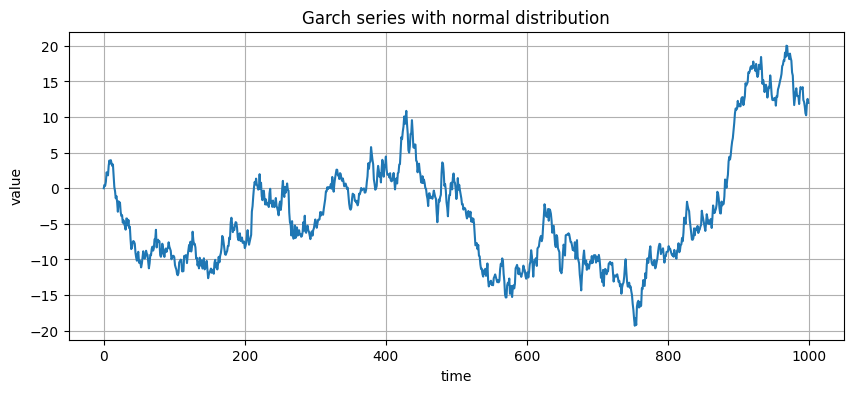

In [217]:
np.random.seed(42)
r_norm, sigma2_norm = simulate_garch_process(OMEGA, ALPHA, BETA, T, np.random.normal, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_norm))
plt.title("Garch series with normal distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [218]:
normal_model = garch11(dist='norm')
normal_model.fit(r_norm[:-PREDICTION_STEPS])
normal_model.summary()

'mu: 0.01951672648682146, omega: 0.1038438060901884, alpha: 0.07481007405889567, beta: 0.8097121634573945'

In [219]:
forecasts_normal = normal_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecasts_normal)


Прогноз дисперсии на 20 шагов:
[1.34038146 1.28944101 1.24438306 1.20452829 1.16927586 1.13809431
 1.11051353 1.08611772 1.06453908 1.0454523  1.02856961 1.0136365
 1.00042783 0.98874447 0.97841028 0.96926945 0.96118419 0.9540326
 0.94770685 0.94211159]


In [220]:
resid_norm = normal_model.resid  # r_t
cond_vol_norm = normal_model.conditional_volatility  # sigma_t
std_resid_norm = resid_norm / cond_vol_norm # z_t

#### Построим график оценённой волатильности / реальной

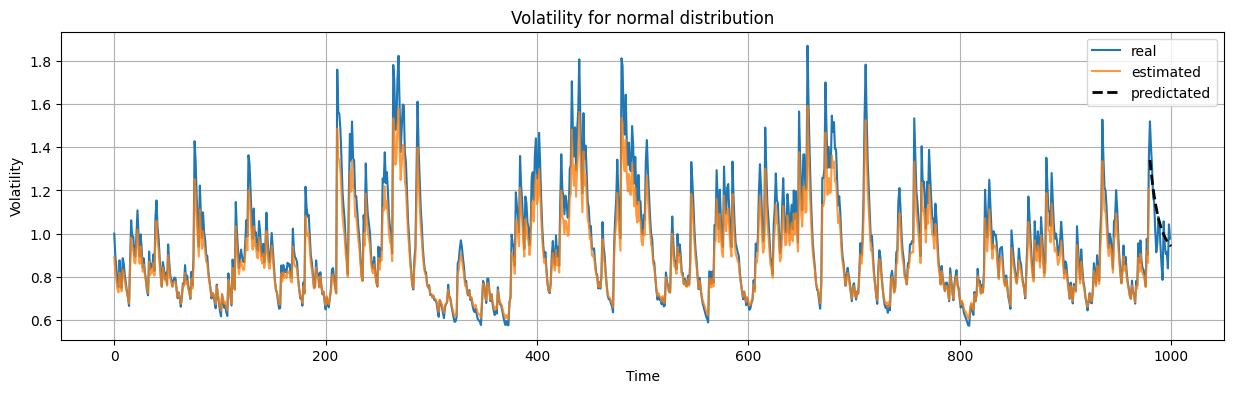

In [221]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_norm, label="real")
plt.plot(cond_vol_norm, color='tab:orange', label="estimated", alpha=0.8)

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS)
plt.plot(x_predicted, np.array(forecasts_normal), color='black', linestyle='--', linewidth=2, label="predictated")

plt.title("Volatility for normal distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Средняя квадратическая ошибка оценки

In [131]:
norm_mse = ((normal_model.conditional_volatility - sigma2_norm[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.0083


#### Средняя квадратическая ошибка прогноза

In [267]:
norm_mse_forecast = ((np.array(forecasts_normal) - sigma2_norm[-PREDICTION_STEPS:]) ** 2).mean()
print(f"MSE : {norm_mse_forecast:.4f}")

MSE : 0.0118


#### Оценим параметры нормального распределения (математическое ожидание и дисперсию)

In [132]:
print(f"Estimated mean: {np.mean(std_resid_norm)}")
print(f"Estimated variance: {np.var(std_resid_norm)}")

Estimated mean: -0.04593569320448665
Estimated variance: 1.003879645597064


### 2.2. Variance Gamma

In [224]:
from scipy import special

def vg_rvs(mu, theta, sigma, nu):
    """
    Генерация случайных чисел из VG распределения
    """
    # 1. Генерируем случайное время из гамма-распределения
    # Параметры: shape = 1/nu, scale = nu [citation:3]
    g = np.random.gamma(shape=1/nu, scale=nu)
    
    # 2. Условное нормальное распределение:
    # VG = theta * g + sigma * sqrt(g) * N(0,1)
    # где g - сгенерированное гамма-время
    normal = np.random.normal(0, 1)
    vg = theta * g + sigma * np.sqrt(g) * normal + mu
    
    return vg

def vg_pdf_one_point(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function in a point x '''
	temp1 = 2.0 / ( sigma*(2.0*np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
	temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
	temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
	temp4 = special.kv(1/nu - 0.5, abs(x-c)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
	return temp1*temp2*temp3*temp4

def vg_pdf(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function of an array or a point x '''
	if isinstance(x, (int, float)): # works with lists and arrays
		return vg_pdf_one_point(x, c, sigma, theta, nu)
	else:
		return [vg_pdf_one_point(xi, c, sigma, theta, nu) for xi in x]

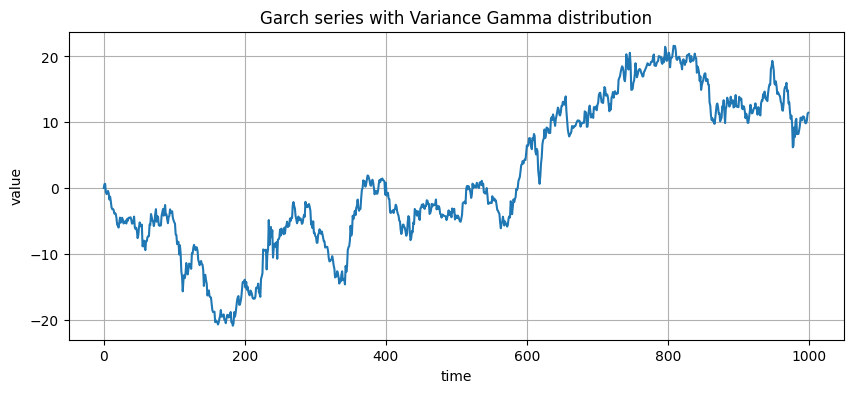

In [255]:
np.random.seed(36)
r_vg, sigma2_vg = simulate_garch_process(OMEGA, ALPHA, BETA, T, vg_rvs, 0, 0, 1, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_vg))
plt.title("Garch series with Variance Gamma distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [256]:
vg_model = garch11(dist='vg')
vg_model.fit(r_vg[:-PREDICTION_STEPS])
vg_model.summary()

/tmp/ipykernel_3752/2995449976.py:88: RuntimeWarning: overflow encountered in exp
  temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
/tmp/ipykernel_3752/2995449976.py:90: RuntimeWarning: invalid value encountered in scalar multiply
  return temp1*temp2*temp3*temp4


'mu: -0.227854888609348, omega: 0.0899378634497635, alpha: 0.10811203810279942, beta: 0.8205122262901177'

In [257]:
forecast_vg = vg_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_vg)


Прогноз дисперсии на 20 шагов:
[2.69514685 2.59271662 2.49759743 2.40926744 2.32724207 2.25107132
 2.18033731 2.11465199 2.05365502 1.99701174 1.94441142 1.89556549
 1.85020597 1.80808402 1.76896856 1.73264499 1.69891404 1.66759067
 1.63850302 1.61149153]


In [258]:
resid_vg = vg_model.resid  # r_t
cond_vol_vg = vg_model.conditional_volatility  # sigma_t
std_resid_vg = resid_vg / cond_vol_vg # z_t

#### Построим график оценённой волатильности / реальной

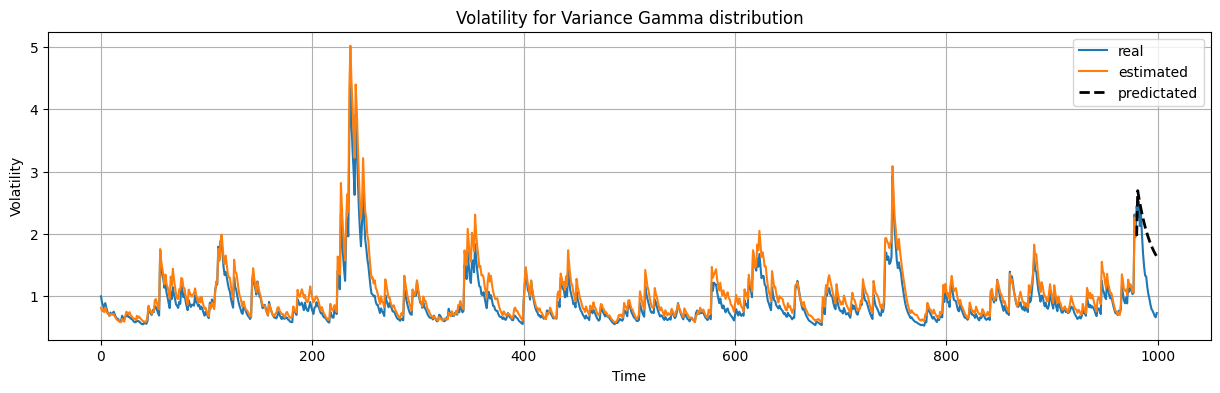

In [266]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_vg, label="real")
plt.plot(cond_vol_vg, color='tab:orange', label="estimated")

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS + 1)
plt.plot(x_predicted, np.append(cond_vol_vg[-1], forecast_vg), color='black', linestyle='--', linewidth=2, label="predictated")

plt.title("Volatility for Variance Gamma distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Оценка параметров Variance Gamma распределения ($\mu,\ \sigma,\ \theta,\ \nu$)

In [140]:
def vg_moments_method(x):
	mu = np.mean(x)
	sigma_squared = np.mean( (x-mu)**2 )
	beta = np.mean( (x-mu)**3 ) / np.mean( (x-mu)**2 )**1.5
	kapa = np.mean( (x-mu)**4 ) / np.mean( (x-mu)**2 )**2
	sigma = sigma_squared**0.5
	nu = kapa/3.0 - 1.0
	theta = sigma*beta / (3.0*nu)
	c = mu - theta
	return (c, sigma, theta, nu)

vg_moments = vg_moments_method(std_resid_vg)
print("mu:", vg_moments[0], "sigma:", vg_moments[1], "theta:", vg_moments[2], "nu:", vg_moments[3])

mu: 0.04460129090717881 sigma: 1.0888556180785796 theta: -0.008660254082210444 nu: 1.0487716812664885


#### Среднеквадратичная ошибка оценки волатильности

In [139]:
norm_mse = ((vg_model.conditional_volatility - sigma2_vg[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.1826


#### Средняя квадратическая ошибка прогноза

In [269]:
vg_mse_forecast = ((np.array(forecast_vg) - sigma2_vg[-PREDICTION_STEPS:]) ** 2).mean()
print(f"MSE : {vg_mse_forecast:.4f}")

MSE : 0.5215


#### 3. $\alpha$-устойчивое распределение

В качестве $\alpha$ выберем 1.9

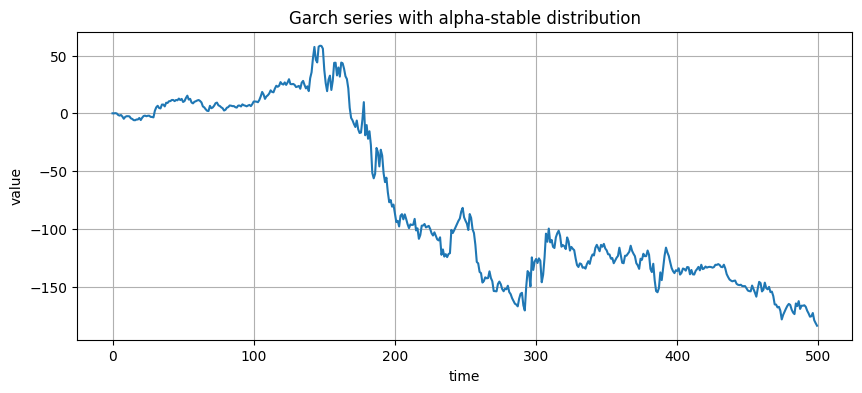

In [287]:
np.random.seed(2)
r_alpha_stable, sigma2_as = simulate_garch_process(OMEGA, ALPHA, BETA, 500, stats.levy_stable.rvs, 1.9, 0, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_alpha_stable))
plt.title("Garch series with alpha-stable distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [288]:
as_model = garch11(dist='as')
as_model.fit(r_alpha_stable[:-PREDICTION_STEPS])
as_model.summary()

'mu: -0.13376301563137852, omega: 0.04546511644731086, alpha: 0.11415886914091898, beta: 0.8067787132065101'

In [289]:
forecast_as = as_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_as)


Прогноз дисперсии на 20 шагов:
[7.0952188  6.57971876 6.10497541 5.66776641 5.26512421 4.89431588
 4.55282455 4.23833235 3.94870466 3.68197564 3.43633486 3.21011504
 3.0017807  2.80991777 2.633224   2.47050006 2.32064147 2.18263106
 2.05553209 1.93848187]


In [290]:
resid_as = as_model.resid  # r_t
cond_vol_as = as_model.conditional_volatility  # sigma_t
std_resid_as = resid_as / cond_vol_as # z_t

#### График оценённой волатильности / реальной

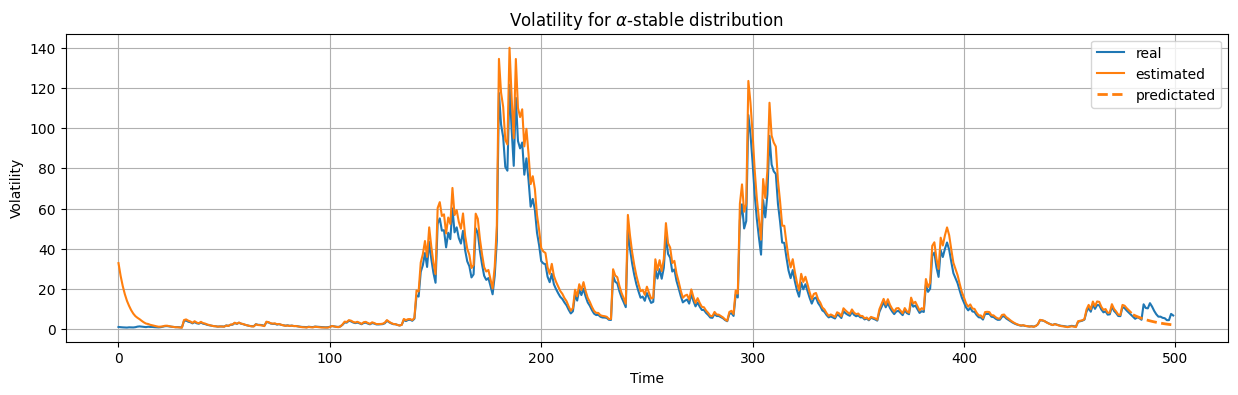

In [291]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_as, label="real")
plt.plot(cond_vol_as, color='tab:orange', label="estimated")

x_predicted = np.linspace(len(sigma2_as) - PREDICTION_STEPS, len(sigma2_as), PREDICTION_STEPS)
plt.plot(x_predicted, forecast_as, color='tab:orange', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for $\alpha$-stable distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Оценка параметров распределения

In [312]:
moments = stats.levy_stable.fit(std_resid_as)
print(rf"$\mu$ = {moments[2]}, $\alpha$ = {moments[0]}, $\sigma$ = {moments[3]}, $\beta$ = {moments[1]}, ")

$\mu$ = -0.0001891831230137383, $\alpha$ = 1.2701935491776755, $\sigma$ = 0.2618166241582117, $\beta$ = 0.0726141875083785, 


#### Среднеквадратчная ошибка волатильности

In [292]:
norm_mse = ((as_model.conditional_volatility - sigma2_as[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 27.9644


#### Средняя квадратическая ошибка прогноза

In [293]:
as_mse_forecast = ((np.array(forecast_as) - sigma2_as[-PREDICTION_STEPS:]) ** 2).mean()
print(f"MSE : {as_mse_forecast:.4f}")

MSE : 20.7181


## 3. GARCH(1,1) на реальных данных

In [294]:
returns_nonscaled = returns['MSFT']
returns_scaled = returns['MSFT'] * 100

### 3.1. Нормальное распределение

#### Оценка параметров модели

In [295]:
real_norm_model = garch11(dist='norm')
real_norm_model.fit(returns_scaled.to_numpy()[:-PREDICTION_STEPS])
real_norm_model.summary()

'mu: 0.11499203213027909, omega: 0.14879853857958883, alpha: 0.059346038586831136, beta: 0.8747073788162821'

In [296]:
resid_r_norm = real_norm_model.resid  # r_t
cond_vol_r_norm = real_norm_model.conditional_volatility  # sigma_t
std_resid_norm = resid_r_norm / cond_vol_r_norm # z_t

#### Оценка параметров распределения

In [297]:
print(f"Estimated mean: {np.mean(std_resid_norm)}")
print(f"Estimated variance: {np.var(std_resid_norm)}")

Estimated mean: 0.04824919768176142
Estimated variance: 0.48654064029885846


#### Прогноз волатильности

In [298]:
forecast_r_norm = real_norm_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_r_norm)


Прогноз дисперсии на 20 шагов:
[2.05327344 2.06666562 2.07917462 2.0908587  2.10177225 2.11196609
 2.12148768 2.13038136 2.13868853 2.14644787 2.1536955  2.16046518
 2.16678843 2.17269467 2.17821142 2.18336436 2.18817748 2.19267319
 2.19687243 2.20079474]


#### График волатильности

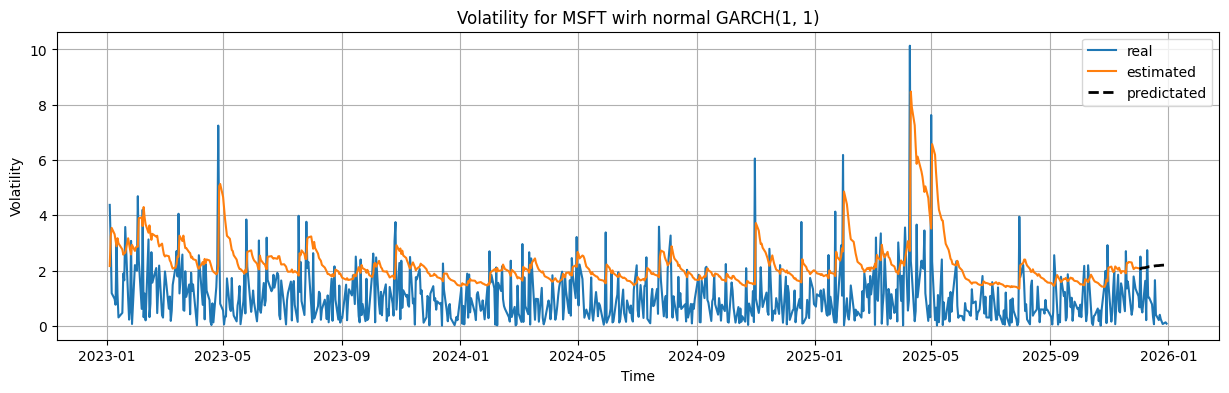

In [299]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(np.abs(returns_scaled), label="real")
plt.plot(returns_scaled.index[:-PREDICTION_STEPS], cond_vol_r_norm, color='tab:orange', label="estimated")
plt.plot(returns_scaled.index[-PREDICTION_STEPS:], forecast_r_norm, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for MSFT wirh normal GARCH(1, 1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Среднеквадратическая ошибка оценки

In [300]:
r_norm_mse = ((real_norm_model.conditional_volatility - np.abs(returns_scaled[:-PREDICTION_STEPS])) ** 2).mean()
print(f"MSE : {r_norm_mse:.4f}")

MSE : 2.8484


#### Среднеквадратическая ошибка прогноза

In [305]:
r_norm_mse_forecast = ((forecast_r_norm - np.abs(returns_scaled[-PREDICTION_STEPS:])) ** 2).mean()
print(f"MSE : {r_norm_mse_forecast:.4f}")

MSE : 2.5341


### 3.2. Variance Gamma

#### Оценка параметров модели

In [301]:
real_vg_model = garch11(dist='vg')
real_vg_model.fit(returns_scaled.to_numpy()[:-PREDICTION_STEPS])
real_vg_model.summary()

'mu: -0.36077650845440024, omega: 1.0369572520402561, alpha: 0.014815873277322405, beta: 0.14718291747771728'

In [302]:
resid_r_vg = real_vg_model.resid  # r_t
cond_vol_r_vg = real_vg_model.conditional_volatility  # sigma_t
std_resid_vg = resid_r_vg / cond_vol_r_vg # z_t

#### Оценка параметров распределения

In [303]:
def vg_moments_method(x):
	mu = np.mean(x)
	sigma_squared = np.mean( (x-mu)**2 )
	beta = np.mean( (x-mu)**3 ) / np.mean( (x-mu)**2 )**1.5
	kapa = np.mean( (x-mu)**4 ) / np.mean( (x-mu)**2 )**2
	sigma = sigma_squared**0.5
	nu = kapa/3.0 - 1.0
	theta = sigma*beta / (3.0*nu)
	c = mu - theta
	return (c, sigma, theta, nu)

vg_moments = vg_moments_method(std_resid_vg)
print("mu:", vg_moments[0], "sigma:", vg_moments[1], "theta:", vg_moments[2], "nu:", vg_moments[3])

mu: -0.02714225453359362 sigma: 1.1669252293942063 theta: 0.11905373525634166 nu: 1.8172191350623597


#### Прогноз волатильности

In [304]:
forecast_r_vg = real_vg_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_r_vg)


Прогноз дисперсии на 20 шагов:
[1.2312385  1.2364164  1.23725521 1.2373911  1.23741311 1.23741668
 1.23741726 1.23741735 1.23741737 1.23741737 1.23741737 1.23741737
 1.23741737 1.23741737 1.23741737 1.23741737 1.23741737 1.23741737
 1.23741737 1.23741737]


#### График волатильности

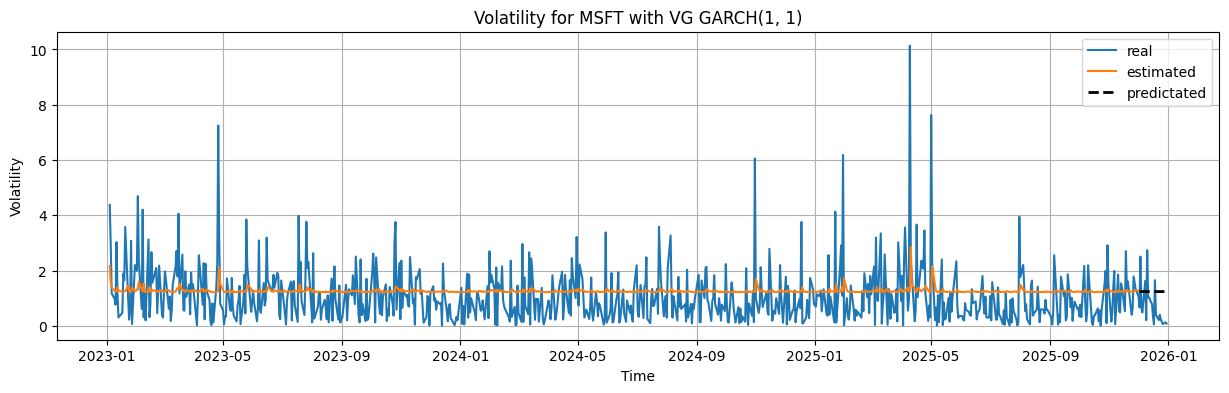

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(np.abs(returns_scaled), label="real")
plt.plot(returns_scaled.index[:-PREDICTION_STEPS], cond_vol_r_vg, color='tab:orange', label="estimated")
plt.plot(returns_scaled.index[-PREDICTION_STEPS:], forecast_r_vg, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for MSFT with VG GARCH(1, 1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Среднеквадратическая ошибка

In [ ]:
r_vg_mse = ((real_vg_model.conditional_volatility - np.abs(returns_scaled[:-PREDICTION_STEPS])) ** 2).mean()
print(f"MSE : {r_vg_mse:.4f}")

MSE : 1.0691


#### Среднеквадратическая ошибка прогноза

In [306]:
r_vg_mse_forecast = ((forecast_r_vg - np.abs(returns_scaled[-PREDICTION_STEPS:])) ** 2).mean()
print(f"MSE : {r_vg_mse_forecast:.4f}")

MSE : 0.8208


### 3. $\alpha$-устойчивое распределение

#### Оценка параметров модели

In [ ]:
real_as_model = garch11(dist='as')
real_as_model.fit(returns_scaled.to_numpy()[:-PREDICTION_STEPS])
real_as_model.summary()

'mu: 0.12693946079531537, omega: 0.09142235444068995, alpha: 0.026332432149939168, beta: 0.8492665376730935'

In [ ]:
resid_r_as = real_as_model.resid  # r_t
cond_vol_r_as = real_as_model.conditional_volatility  # sigma_t
std_resid_r_as = resid_r_as / cond_vol_r_as # z_t

#### Оценка параметров распределения

In [313]:
moments = stats.levy_stable.fit(std_resid_r_as)
print(rf"$\mu$ = {moments[2]}, $\alpha$ = {moments[0]}, $\sigma$ = {moments[3]}, $\beta$ = {moments[1]}, ")

$\mu$ = 0.08788552850081721, $\alpha$ = 1.7669488466066339, $\sigma$ = 0.9060750672183118, $\beta$ = -0.17339965196219054, 


#### Прогноз волатильности

In [308]:
forecast_r_as = real_as_model.predict(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
print(forecast_r_as)


Прогноз дисперсии на 20 шагов:
[0.92309144 0.89968027 0.87918147 0.86123274 0.84551686 0.83175604
 0.81970709 0.80915704 0.79991942 0.79183098 0.78474874 0.77854754
 0.77311778 0.76836349 0.76420063 0.76055564 0.75736409 0.75456957
 0.75212269 0.74998021]


#### График волатильности

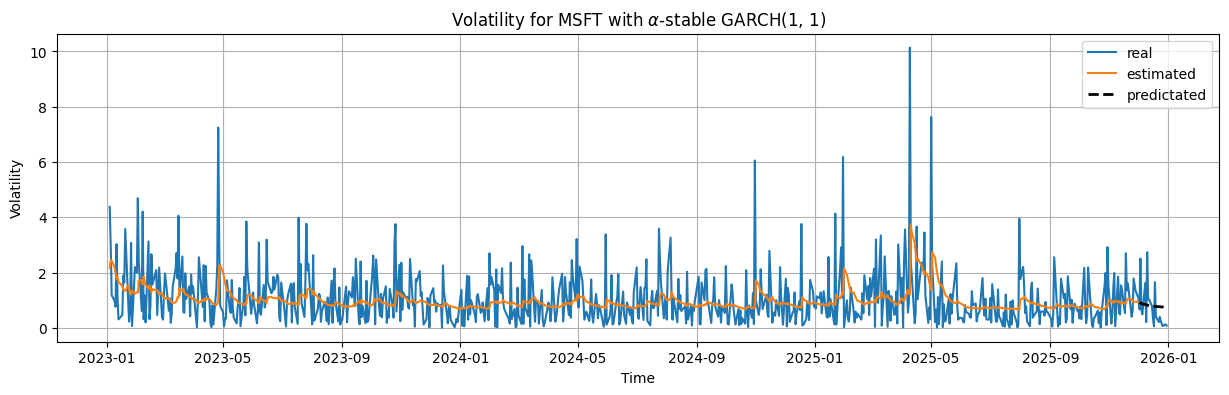

In [309]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(np.abs(returns_scaled), label="real")
plt.plot(returns_scaled.index[:-PREDICTION_STEPS], cond_vol_r_as, color='tab:orange', label="estimated")
plt.plot(returns_scaled.index[-PREDICTION_STEPS:], forecast_r_as, color='black', linestyle='--', linewidth=2, label="predictated")

plt.title(fr"Volatility for MSFT with $\alpha$-stable GARCH(1, 1)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid()
plt.show()

#### Среднеквадратическая ошибка

In [310]:
r_as_mse = ((real_as_model.conditional_volatility - np.abs(returns_scaled[:-PREDICTION_STEPS])) ** 2).mean()
print(f"MSE : {r_as_mse:.4f}")

MSE : 1.0715


#### Среднеквадратическая ошибка прогноза

In [311]:
r_as_mse_forecast = ((forecast_r_as - np.abs(returns_scaled[-PREDICTION_STEPS:])) ** 2).mean()
print(f"MSE : {r_as_mse_forecast:.4f}")

MSE : 0.5636
